In [ ]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud, STOPWORDS
import re
import string

from collections import Counter

In [ ]:
# Load your scraped data
df = pd.read_excel("/content/FinBERT_Title_Only_Labeled.xlsx")

# Choose the text column
text_column = "title"

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df["clean_text"] = df[text_column].apply(clean_text)

# Combine all text into one string
all_text = " ".join(df["clean_text"])

In [ ]:
custom_stopwords = set(STOPWORDS)

# add domain-specific stopwords
custom_stopwords.update([
    "amd", "company", "stock", "stocks", "market",
    "said", "says", "will", "also", "one", "new"
])

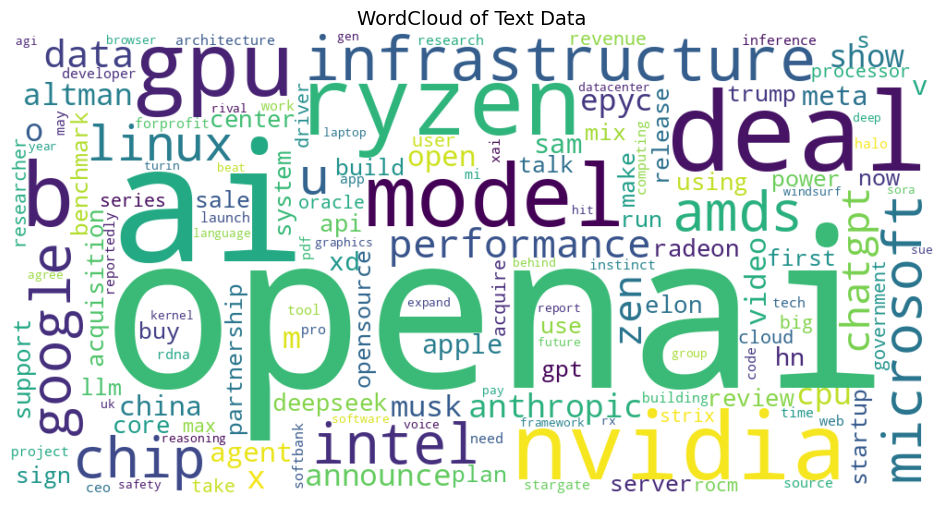

In [ ]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Text Data", fontsize=14)
plt.show()


In [ ]:
# Load your scraped data
df = pd.read_excel("/content/FinBERT_Title_and_Post_Labeled.xlsx")   # <-- change filename

# Choose the text column
text_column = "full_text"   # e.g. "title", "post", "content"


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
custom_stopwords = set(STOPWORDS)

# Optional: add domain-specific stopwords
custom_stopwords.update([
    "amd", "company", "stock", "stocks", "market",
    "said", "says", "will", "also", "one", "new"
])


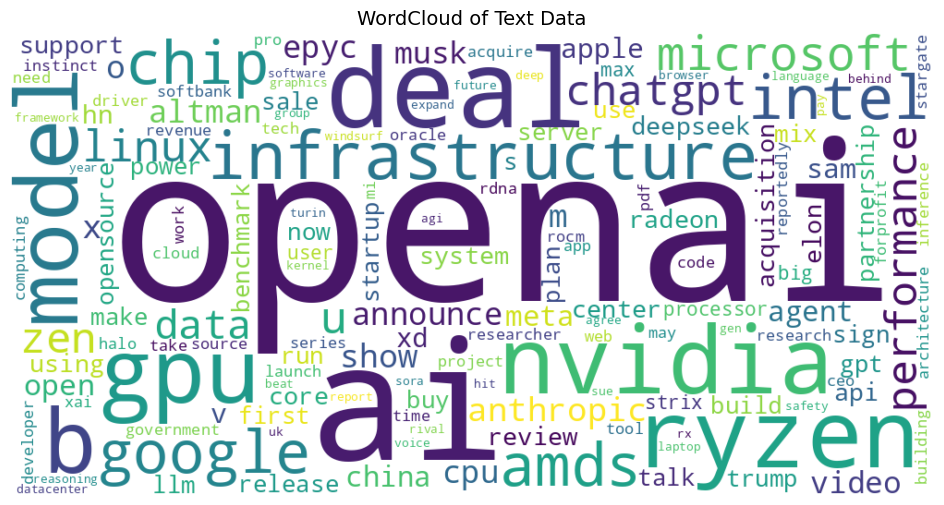

In [ ]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=custom_stopwords,
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Text Data", fontsize=14)
plt.show()


 ## **EDA**

## Title Only

In [ ]:
# Example column names (edit if needed)
df = pd.read_excel("/content/FinBERT_Title_Only_Labeled.xlsx")

TEXT_COL = "title"        # or "title", "post"
DATE_COL = "date"        # optional
SENT_COL = "finbert_label"   # optional

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn info:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (2826, 8)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2826 entries, 0 to 2825
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   keyword          2826 non-null   object        
 1   title            2826 non-null   object        
 2   hn_link          2826 non-null   object        
 3   created_at_i     2826 non-null   int64         
 4   date             2826 non-null   datetime64[ns]
 5   post             0 non-null      float64       
 6   finbert_label    2826 non-null   object        
 7   sentiment_score  2826 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 176.8+ KB
None

Missing values:
keyword               0
title                 0
hn_link               0
created_at_i          0
date                  0
post               2826
finbert_label         0
sentiment_score       0
dtype: int64


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)


count    2826.000000
mean        9.574664
std         2.699770
min         1.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        18.000000
Name: text_length, dtype: float64


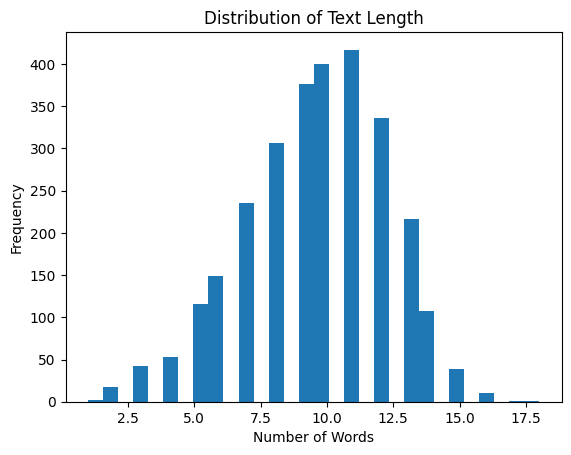

In [ ]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

print(df["text_length"].describe())

plt.figure()
plt.hist(df["text_length"], bins=30)
plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


              Word  Frequency
0           openai       1153
1               ai        670
2          openais        193
3             deal        179
4            ryzen        161
5                b        143
6           nvidia        141
7   infrastructure        136
8                –        122
9             amds        109
10           intel        108
11       microsoft         96
12          google         95
13              us         91
14           linux         90
15     performance         89
16             zen         86
17            says         82
18            gpus         81
19          models         79


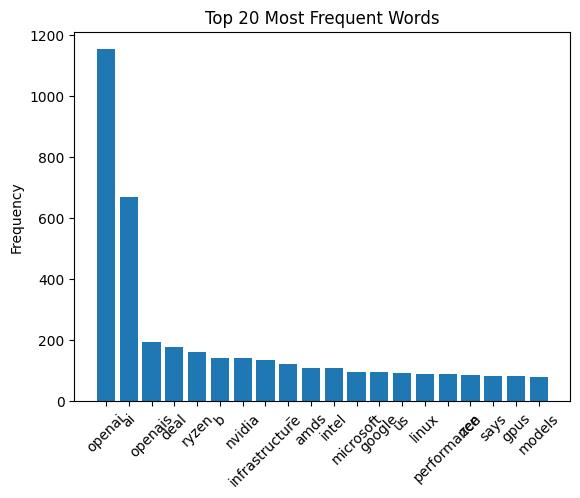

In [ ]:
stopwords = set(STOPWORDS)
stopwords.update([
    "amd", "stock", "market", "company", "said",
    "will", "also", "one", "new"
])

words = []
for text in df["clean_text"]:
    words.extend([w for w in text.split() if w not in stopwords])

word_freq = Counter(words).most_common(20)

# Convert to DataFrame
freq_df = pd.DataFrame(word_freq, columns=["Word", "Frequency"])
print(freq_df)

plt.figure()
plt.bar(freq_df["Word"], freq_df["Frequency"])
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.ylabel("Frequency")
plt.show()


finbert_label
neutral     2040
positive     416
negative     370
Name: count, dtype: int64


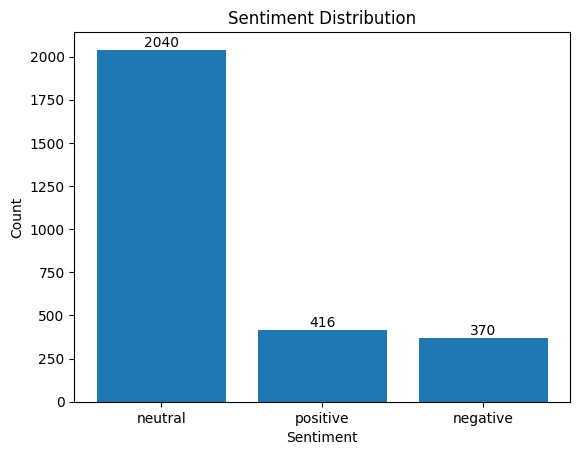

In [ ]:
if SENT_COL in df.columns:
    sentiment_counts = df[SENT_COL].value_counts()
    print(sentiment_counts)

    plt.figure()
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values)
    plt.title("Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.bar_label(bars)
    plt.show()

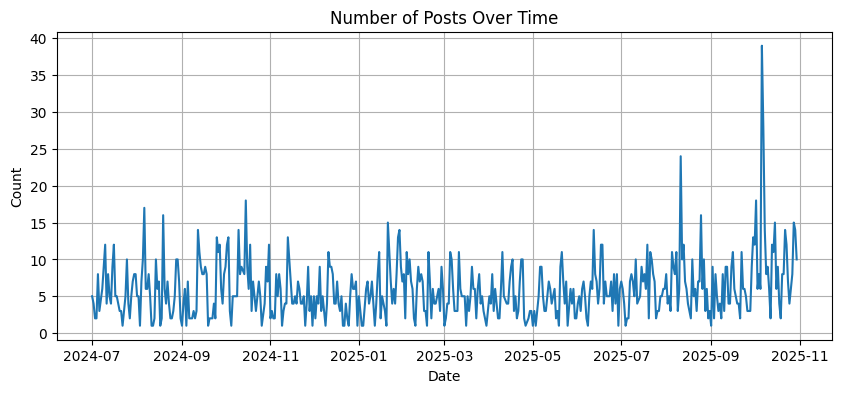

In [ ]:
if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    daily_counts = df.groupby(df[DATE_COL].dt.date).size()

    plt.figure(figsize=(10,4))
    plt.plot(daily_counts.index, daily_counts.values)
    plt.title("Number of Posts Over Time")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


## Title+Post

In [ ]:
# Example column names (edit if needed)
df = pd.read_excel("/content/FinBERT_Title_and_Post_Labeled.xlsx")

TEXT_COL = "full_text"        # or "title", "post"
DATE_COL = "date"        # optional
SENT_COL = "finbert_label"   # optional

In [ ]:
print("Dataset shape:", df.shape)
print("\nColumn info:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

Dataset shape: (2113, 9)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113 entries, 0 to 2112
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   keyword          2113 non-null   object        
 1   title            2113 non-null   object        
 2   hn_link          2113 non-null   object        
 3   created_at_i     2113 non-null   int64         
 4   date             2113 non-null   datetime64[ns]
 5   post             2113 non-null   object        
 6   full_text        2113 non-null   object        
 7   finbert_label    2113 non-null   object        
 8   sentiment_score  2113 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 148.7+ KB
None

Missing values:
keyword            0
title              0
hn_link            0
created_at_i       0
date               0
post               0
full_text          0
finbert_label      0
sentiment_s

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)


count    2113.000000
mean      237.748699
std       160.142685
min         4.000000
25%       120.000000
50%       193.000000
75%       315.000000
max      1061.000000
Name: text_length, dtype: float64


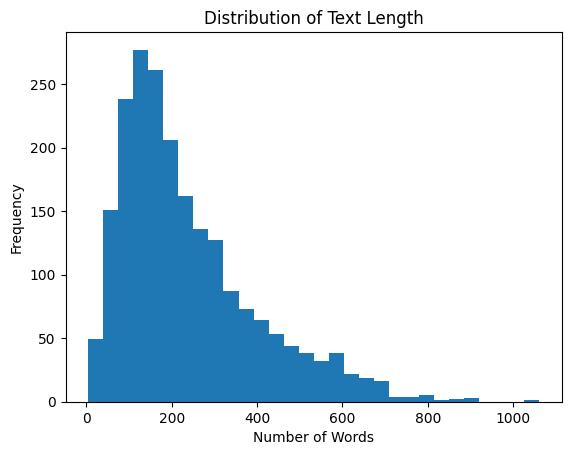

In [ ]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))

print(df["text_length"].describe())

plt.figure()
plt.hist(df["text_length"], bins=30)
plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


        Word  Frequency
0         ai       3501
1         hn       2494
2       data       1565
3       show       1328
4      built       1302
5          –       1236
6        use       1192
7       code       1117
8   feedback        961
9      using        950
10      time        906
11     tools        876
12    models        874
13  building        866
14       api        857
15    openai        857
16      love        813
17      work        788
18      make        765
19       now        739


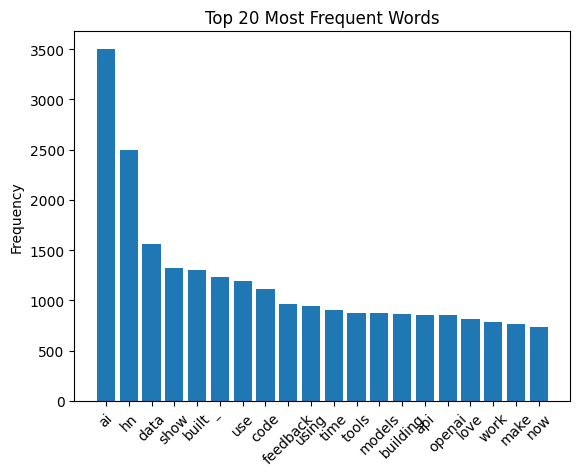

In [ ]:
stopwords = set(STOPWORDS)
stopwords.update([
    "amd", "stock", "market", "company", "said",
    "will", "also", "one", "new"
])

words = []
for text in df["clean_text"]:
    words.extend([w for w in text.split() if w not in stopwords])

word_freq = Counter(words).most_common(20)

# Convert to DataFrame
freq_df = pd.DataFrame(word_freq, columns=["Word", "Frequency"])
print(freq_df)

plt.figure()
plt.bar(freq_df["Word"], freq_df["Frequency"])
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.ylabel("Frequency")
plt.show()


finbert_label
neutral     1922
negative     136
positive      55
Name: count, dtype: int64


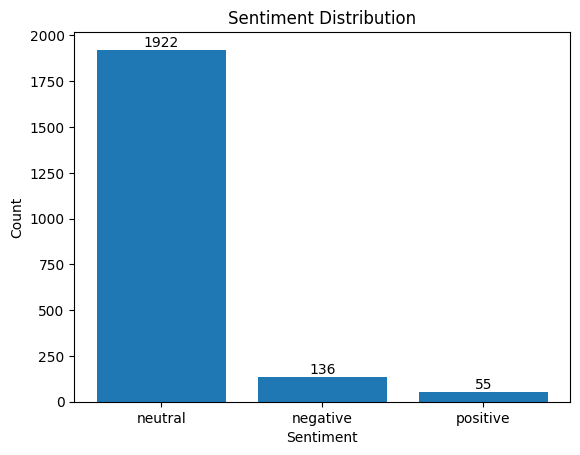

In [ ]:
if SENT_COL in df.columns:
    sentiment_counts = df[SENT_COL].value_counts()
    print(sentiment_counts)

    plt.figure()
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values)
    plt.title("Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.bar_label(bars)
    plt.show()

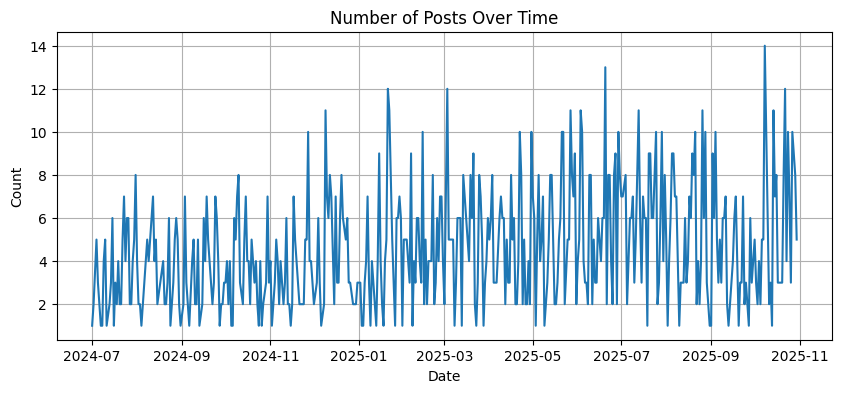

In [ ]:
if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    daily_counts = df.groupby(df[DATE_COL].dt.date).size()

    plt.figure(figsize=(10,4))
    plt.plot(daily_counts.index, daily_counts.values)
    plt.title("Number of Posts Over Time")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()


### Sentiment Distribution for Title Only Data

label
neutral     175
positive    164
negative     11
Name: count, dtype: int64


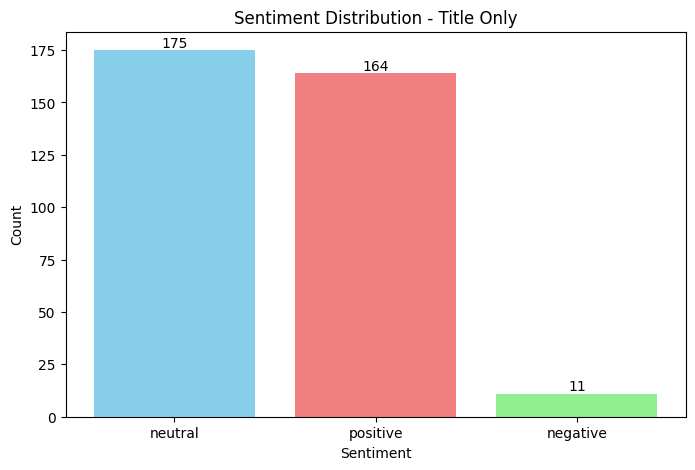

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the 'Title Only' data
df_title_only = pd.read_excel("/content/HN_AMD_Title_Only_Labeled_FinalFinal.xlsx")
SENT_COL_TITLE = "label"

sentiment_counts_title = df_title_only[SENT_COL_TITLE].value_counts()
print(sentiment_counts_title)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    sentiment_counts_title.index,
    sentiment_counts_title.values,
    color=['skyblue', 'lightcoral', 'lightgreen']
)

plt.title("Sentiment Distribution - Title Only")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.bar_label(bars)
plt.show()

### Sentiment Distribution for Title + Post Data

label
positive    242
neutral      57
negative     37
Name: count, dtype: int64


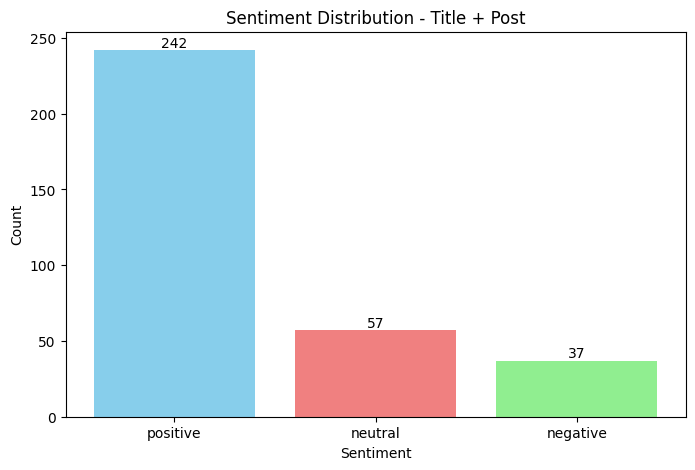

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the 'Title + Post' data
df_title_post = pd.read_excel("/content/HN_AMD_Title_and_Post_Labeled_FinalFinal.xlsx")
SENT_COL_POST = "label"

sentiment_counts_post = df_title_post[SENT_COL_POST].value_counts()
print(sentiment_counts_post)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    sentiment_counts_post.index,
    sentiment_counts_post.values,
    color=['skyblue', 'lightcoral', 'lightgreen']
)

plt.title("Sentiment Distribution - Title + Post")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.bar_label(bars)
plt.show()